## Objetivo

Neste notebook, realizamos a etapa de modelagem preditiva, utilizando o dataset sintético gerado anteriormente.
O foco é treinar, comparar e ajustar modelos de machine learning capazes de prever a probabilidade de inadimplência de clientes bancários.

## Etapas Principais

### 1. Configuração do ambiente 

- O notebook é compatível com **Google Colab e VS Code**.
- Detecta automaticamente o ambiente de execução e ajusta os caminhos de      leitura e gravação.

---

### 2. Carregamento e análise dos dados

- Leitura do arquivo clientes_sinteticos.csv.
- Verificação de valores nulos, tipos de variáveis e estatísticas descritivas.

---

### 3. Pré-processamento

- Separação entre variáveis independentes (X) e variável-alvo (y).
- Divisão dos dados em conjuntos de treino e teste.
- Padronização dos dados numéricos com StandardScaler

---

### 4. Treinamento dos modelos

- Avaliação inicial com métricas de Acurácia e F1-Score.
- Visualização das matrizes de confusão para cada modelo.

 **Modelos utilizados:**

 - Regressão Logística
 - Árvore de Decisão
 - Random Forest

---

### 5. Comparação e interpretação automática

- Comparação entre os modelos com base no desempenho.
- Identificação automática do modelo com melhor F1-Score e análise qualitativa dos resultados.

---

### 6. Ajuste de hiperparâmetros (Grid Search)

- Aplicação do GridSearchCV para otimizar os parâmetros da Regressão Logística e da Random Forest.
- Comparação dos resultados ajustados e visualização das novas matrizes de confusão

---

### 7. Exportação dos resultados

- Salvamento dos resultados comparativos antes e após o tuning nos arquivos:
- resultados_modelagem.csv
- resultados_modelagem_tuning.csv

---

### Resultado esperado

Ao final, o notebook apresenta:

 - Um ranking dos modelos com suas métricas de desempenho;
 - Matrizes de confusão comparativas;
 - Os melhores parâmetros encontrados via Grid Search;
 - Arquivos com resultados salvos para serem utilizados na próxima etapa do projeto (agente de IA explicativo).



 Dataset encontrado em: c:\Users\Nycolle\agente-ia\notebooks\../data\clientes_sinteticos.csv
✅ Dataset carregado com sucesso! 5000 linhas.

Valores nulos por coluna:
client_id             0
idade                 0
renda_mensal          0
tempo_emprego_anos    0
qtd_contas            0
score_credito         0
historico_atrasos     0
valor_emprestimo      0
parcelas              0
inadimplente          0
dtype: int64

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   client_id           5000 non-null   int64  
 1   idade               5000 non-null   int64  
 2   renda_mensal        5000 non-null   float64
 3   tempo_emprego_anos  5000 non-null   float64
 4   qtd_contas          5000 non-null   int64  
 5   score_credito       5000 non-null   float64
 6   historico_atrasos   5000 non-null   int64  
 7   val

,client_id,idade,renda_mensal,tempo_emprego_anos,qtd_contas,score_credito,historico_atrasos,valor_emprestimo,parcelas,inadimplente
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,2500.500000,46.148600,4025.946856,3.012800,2.037400,600.127816,0.492800,25130.324994,31.12240,0.242600
std,1443.520003,16.325753,3689.348127,3.011737,1.422113,97.694127,0.706858,14412.825615,16.32632,0.428698
min,1.000000,18.000000,169.750000,0.000000,0.000000,300.000000,0.000000,504.630000,3.00000,0.000000
25%,1250.750000,32.000000,1704.770000,0.900000,1.000000,531.662689,0.000000,12358.900000,17.00000,0.000000
50%,2500.500000,46.000000,2900.635000,2.100000,2.000000,601.146959,0.000000,24982.865000,31.00000,0.000000
75%,3750.250000,60.000000,5051.877500,4.200000,3.000000,666.382597,1.000000,37850.322500,45.00000,0.000000
max,5000.000000,74.000000,39819.470000,24.100000,9.000000,850.000000,5.000000,49998.620000,59.00000,1.000000



Formato dos dados:
X: (5000, 8)
y: (5000,)
Tamanho treino: (3500, 8)
Tamanho teste: (1500, 8)

 Comparação de desempenho entre modelos:


,Acurácia,F1-score
Regressão Logística,0.590667,0.416350
Árvore de Decisão,0.636000,0.237430
Random Forest,0.750000,0.074074


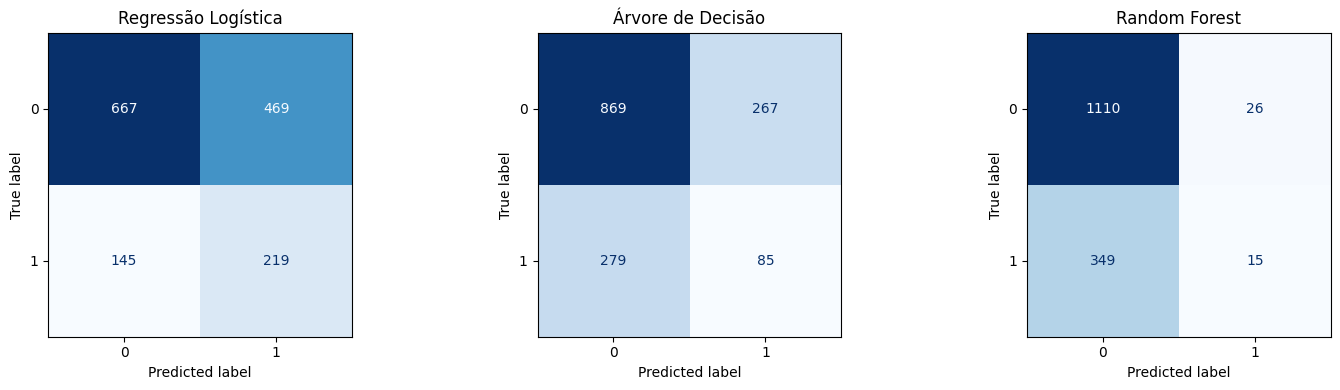


 Interpretação automática:
O modelo com melhor desempenho foi Regressão Logística
- F1-score: 0.4163
- Acurácia: 0.5907
 Melhor equilíbrio entre precisão e sensibilidade.


KeyboardInterrupt: 

In [ ]:

#  02_modelagem.ipynb — Compatível com Colab e VS Code

# 1 Detectar ambiente e configurar caminhos
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/agente-ia/data"
else:
    base_path = os.path.join(os.getcwd(), "../data")  # caminho relativo no VS Code

os.makedirs(base_path, exist_ok=True)
csv_path = os.path.join(base_path, "clientes_sinteticos.csv")

# Verificar se o arquivo existe
if os.path.exists(csv_path):
    print(f" Dataset encontrado em: {csv_path}")
else:
    raise FileNotFoundError(f" Dataset não encontrado! Verifique o caminho: {csv_path}")

# 2 Imports 
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns

# 3 Carregar dataset
df = pd.read_csv(csv_path)
print(f" Dataset carregado com sucesso! {len(df)} linhas.\n")

# 4 Análise inicial
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nInformações do dataset:")
df.info()

print("\nResumo estatístico:")
display(df.describe())

# 5 Preparar os dados
X = df.drop(columns=["inadimplente", "client_id"])
y = df["inadimplente"]

print("\nFormato dos dados:")
print("X:", X.shape)
print("y:", y.shape)

# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste: {X_test.shape}")

# 6 Padronizar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7 Modelos e comparação 
resultados = {}

# 1️ Regressão Logística
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)
resultados["Regressão Logística"] = {
    "Acurácia": accuracy_score(y_test, y_pred_lr),
    "F1-score": f1_score(y_test, y_pred_lr)
}

# 2️ Árvore de Decisão
modelo_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)
resultados["Árvore de Decisão"] = {
    "Acurácia": accuracy_score(y_test, y_pred_dt),
    "F1-score": f1_score(y_test, y_pred_dt)
}

# 3️ Random Forest
modelo_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
resultados["Random Forest"] = {
    "Acurácia": accuracy_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf)
}

# 8 Resultados comparativos 
tabela_resultados = pd.DataFrame(resultados).T
print("\n Comparação de desempenho entre modelos:")
display(tabela_resultados)

# 9 Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nome, y_pred) in zip(axes, [
    ("Regressão Logística", y_pred_lr),
    ("Árvore de Decisão", y_pred_dt),
    ("Random Forest", y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_rf.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

# 10 Interpretação automática
melhor_modelo = tabela_resultados["F1-score"].idxmax()
melhor_f1 = tabela_resultados.loc[melhor_modelo, "F1-score"]
melhor_acc = tabela_resultados.loc[melhor_modelo, "Acurácia"]

print("\n Interpretação automática:")
print(f"O modelo com melhor desempenho foi {melhor_modelo}")
print(f"- F1-score: {melhor_f1:.4f}")
print(f"- Acurácia: {melhor_acc:.4f}")

if melhor_modelo == "Regressão Logística":
    print(" Melhor equilíbrio entre precisão e sensibilidade.")
elif melhor_modelo == "Árvore de Decisão":
    print(" Capturou relações não lineares, mas pode ter overfitting.")
elif melhor_modelo == "Random Forest":
    print(" Melhor poder de generalização.")
else:
    print(" Nenhum modelo se destacou claramente.")

# 11 Grid Search (ajuste de hiperparâmetros)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

# 12 Comparar resultados finais ajustados 
tuning_results = pd.DataFrame({
    "Modelo": ["Regressão Logística (Tuned)", "Random Forest (Tuned)"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr_tuned),
        f1_score(y_test, y_pred_rf_tuned)
    ]
})

print("\n Resultados após o ajuste de hiperparâmetros:")
display(tuning_results)
print("\nMelhores parâmetros encontrados:")
print("Regressão Logística:", grid_lr.best_params_)
print("Random Forest:", grid_rf.best_params_)

# 13 Matrizes de confusão dos modelos ajustados
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr_tuned, display_labels=best_lr.classes_)
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Regressão Logística (Ajustada)")

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=best_rf.classes_)
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Random Forest (Ajustada)")

plt.tight_layout()
plt.show()

# 14 Salvar resultados
output_results_path = os.path.join(base_path, "resultados_modelagem.csv")
tabela_resultados.to_csv(output_results_path, index=False)
print(f" Resultados salvos em: {output_results_path}")

output_tuning_path = os.path.join(base_path, "resultados_modelagem_tuning.csv")
tuning_results.to_csv(output_tuning_path, index=False)
print(f" Resultados ajustados salvos em: {output_tuning_path}")

